In [1]:
import kagglehub

ModuleNotFoundError: No module named 'kagglehub'

In [2]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub

In [4]:
print(kagglehub.__version__)

1.0.0


In [5]:
# This will download the latest version to your local Kaggle cache
path = kagglehub.dataset_download("ssssws/online-learning-engagement-dataset")

print("Data is located at:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 2.79M/2.79M [00:01<00:00, 2.37MB/s]

Extracting files...
Data is located at: C:\Users\Dr.Mohamed Atef\.cache\kagglehub\datasets\ssssws\online-learning-engagement-dataset\versions\2


In [6]:
import pandas as pd

df = pd.read_csv(r"D:\PhDResearch\qualificationExams\2026\selectedTopics2\anaconda\dataset\online_learning_engagement_dataset.csv")

print(df.head())
print(df.info())
print(df.describe())

   student_id  age  gender    country device_type  internet_speed_mbps  \
0           1   24  Female        USA      Laptop                44.70   
1           2   37  Female    Germany      Tablet                61.10   
2           3   46  Female  Australia      Tablet                43.10   
3           4   32    Male      India      Tablet                26.99   
4           5   28    Male      India      Laptop                52.28   

   study_hours_weekly  login_frequency_weekly  avg_session_duration_min  \
0               15.92                      10                 40.052752   
1                6.37                       8                 32.442671   
2                6.64                       7                 43.614509   
3               10.91                       5                 30.697263   
4                7.41                       6                 47.402999   

   video_watch_time_min  assignments_submitted  forum_posts  quiz_attempts  \
0            294.099759   

In [7]:
print(df.columns)

Index(['student_id', 'age', 'gender', 'country', 'device_type',
       'internet_speed_mbps', 'study_hours_weekly', 'login_frequency_weekly',
       'avg_session_duration_min', 'video_watch_time_min',
       'assignments_submitted', 'forum_posts', 'quiz_attempts',
       'avg_quiz_score', 'attendance_rate', 'engagement_score', 'final_grade',
       'dropout'],
      dtype='str')


# Let's apply data cleaning step

In [8]:
# Check missing values
print(df.isnull().sum())

# Drop or fill missing
df = df.dropna()

student_id                  0
age                         0
gender                      0
country                     0
device_type                 0
internet_speed_mbps         0
study_hours_weekly          0
login_frequency_weekly      0
avg_session_duration_min    0
video_watch_time_min        0
assignments_submitted       0
forum_posts                 0
quiz_attempts               0
avg_quiz_score              0
attendance_rate             0
engagement_score            0
final_grade                 0
dropout                     0
dtype: int64


# Step 1: Create Classification Target

In [11]:
def classify_engagement(score):
    if score < 40:
        return "Low"
    elif score < 70:
        return "Medium"
    else:
        return "High"

df['engagement_level'] = df['engagement_score'].apply(classify_engagement)

# Step 2: Convert to Numbers

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['engagement_level'] = le.fit_transform(df['engagement_level'])

# Step 3: Define INPUT (X)

## Input = all features except target + useless columns

In [13]:
X = df.drop(['engagement_score', 'engagement_level', 'student_id'], axis=1)
y = df['engagement_level']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
print(X.dtypes)

age                           int64
gender                          str
country                         str
device_type                     str
internet_speed_mbps         float64
study_hours_weekly          float64
login_frequency_weekly        int64
avg_session_duration_min    float64
video_watch_time_min        float64
assignments_submitted         int64
forum_posts                   int64
quiz_attempts                 int64
avg_quiz_score              float64
attendance_rate             float64
final_grade                 float64
dropout                       int64
dtype: object


In [20]:
# Convert categorical to numeric
X = pd.get_dummies(X, drop_first=True)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [21]:
print(X.columns)

Index(['age', 'internet_speed_mbps', 'study_hours_weekly',
       'login_frequency_weekly', 'avg_session_duration_min',
       'video_watch_time_min', 'assignments_submitted', 'forum_posts',
       'quiz_attempts', 'avg_quiz_score', 'attendance_rate', 'final_grade',
       'dropout', 'gender_Male', 'country_Canada', 'country_Germany',
       'country_India', 'country_UK', 'country_USA', 'device_type_Mobile',
       'device_type_Tablet'],
      dtype='str')


### Remove Leakage Features

In [22]:
X = df.drop([
    'engagement_score',
    'engagement_level',
    'student_id',
    'final_grade',
    'dropout'
], axis=1)

In [23]:
print(X.columns)

Index(['age', 'gender', 'country', 'device_type', 'internet_speed_mbps',
       'study_hours_weekly', 'login_frequency_weekly',
       'avg_session_duration_min', 'video_watch_time_min',
       'assignments_submitted', 'forum_posts', 'quiz_attempts',
       'avg_quiz_score', 'attendance_rate'],
      dtype='str')


### Model Will Learn Now

## ✔ Study behavior → engagement
## ✔ Platform usage → engagement
## ✔ Activity patterns → engagement

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [26]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10000

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



### Feature Importance 🔥

In [28]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

age                         0.0
internet_speed_mbps         0.0
study_hours_weekly          0.0
login_frequency_weekly      0.0
avg_session_duration_min    0.0
video_watch_time_min        0.0
assignments_submitted       0.0
forum_posts                 0.0
quiz_attempts               0.0
avg_quiz_score              0.0
dtype: float64

### Problem 1: Feature Importance = 0.0
👉 This means:

Your model did NOT learn anything

### 🚨 Problem 2: Accuracy = 1.0

In [29]:
print(X.columns)

Index(['age', 'internet_speed_mbps', 'study_hours_weekly',
       'login_frequency_weekly', 'avg_session_duration_min',
       'video_watch_time_min', 'assignments_submitted', 'forum_posts',
       'quiz_attempts', 'avg_quiz_score', 'attendance_rate', 'gender_Male',
       'country_Canada', 'country_Germany', 'country_India', 'country_UK',
       'country_USA', 'device_type_Mobile', 'device_type_Tablet'],
      dtype='str')


# 🎯 Combined Diagnosis

#### When you see:

Accuracy = 1.0  +  Importance = 0
### 🔥 Most Likely Causes
## ❌ 1. Data Leakage STILL EXISTS
Even if you removed final_grade, check again:
#### python
print(X.columns)

👉 Make sure:

engagement_score ❌
engagement_level ❌
final_grade ❌
dropout ❌
## ❌ 2. Target (y) is constant

Check this:
#### python
print(y.value_counts())

👉 If you see:

High    1000

👉 Then model always predicts one class → accuracy = 1.0
## ❌ 3. Train/Test Split Problem
Maybe:

#### python
X_train == X_test ❌

Check:

#### python
print(X_train.shape)
print(X_test.shape)
## ❌ 4. Wrong Split Order

Make sure you did:

#### python
#### BEFORE split
X = pd.get_dummies(X, drop_first=True)

#### THEN split
train_test_split(...)

# Step-by-Step Debug

### Step 1: Check Target Distribution

In [31]:
print(y.value_counts())

engagement_level
0    50000
Name: count, dtype: int64


### Step 2: Check Features
only 1 unique value

→ useless feature

In [32]:
print(X.head())
print(X.nunique())

   age  internet_speed_mbps  study_hours_weekly  login_frequency_weekly  \
0   24                44.70               15.92                      10   
1   37                61.10                6.37                       8   
2   46                43.10                6.64                       7   
3   32                26.99               10.91                       5   
4   28                52.28                7.41                       6   

   avg_session_duration_min  video_watch_time_min  assignments_submitted  \
0                 40.052752            294.099759                      3   
1                 32.442671            400.397658                      7   
2                 43.614509            190.239738                      1   
3                 30.697263            370.451629                      3   
4                 47.402999            151.341296                      4   

   forum_posts  quiz_attempts  avg_quiz_score  attendance_rate  gender_Male  \
0            

### Step 3: Check Predictions

#### Python
print(set(y_pred))

👉 If result: {One Value}

👉 Model predicts ONE class only ❌

### ✅ Step 4: Check Accuracy Properly

#### Python


In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0
[[10000]]


D:\InstallationPath\anaconda\envs\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [35]:
print(y.value_counts())

engagement_level
0    50000
Name: count, dtype: int64


### ✅ Use Quantiles (Balanced Classes)

In [36]:
df['engagement_level'] = pd.qcut(
    df['engagement_score'],
    q=3,
    labels=["Low", "Medium", "High"]
)

### Encode Again

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['engagement_level'] = le.fit_transform(df['engagement_level'])

### Verify
#### Python

In [38]:
print(df['engagement_level'].value_counts())

engagement_level
0    16667
1    16667
2    16666
Name: count, dtype: int64


## Rebuild Pipeline

In [86]:
X = df.drop([
    'engagement_score',
    'student_id',
    'final_grade',
    'dropout'
], axis=1)

X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, df['engagement_level'], test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Let's Evaluate again

In [88]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(df['engagement_level'].value_counts())

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3252
           1       1.00      1.00      1.00      3342
           2       1.00      1.00      1.00      3406

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


Confusion Matrix:
 [[3252    0    0]
 [   0 3342    0]
 [   0    0 3406]]
engagement_level
0    16667
1    16667
2    16666
Name: count, dtype: int64


In [89]:
set(y_pred)

{np.int64(0), np.int64(1), np.int64(2)}

# 🔥 Step 5: Feature Importance (NOW IT WILL WORK)

In [90]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

engagement_level            0.687723
study_hours_weekly          0.197263
video_watch_time_min        0.044114
assignments_submitted       0.042266
quiz_attempts               0.018326
internet_speed_mbps         0.001696
avg_quiz_score              0.001682
avg_session_duration_min    0.001680
attendance_rate             0.001306
age                         0.001056
dtype: float64


# 📊 Visualization (Important for research 🔥)

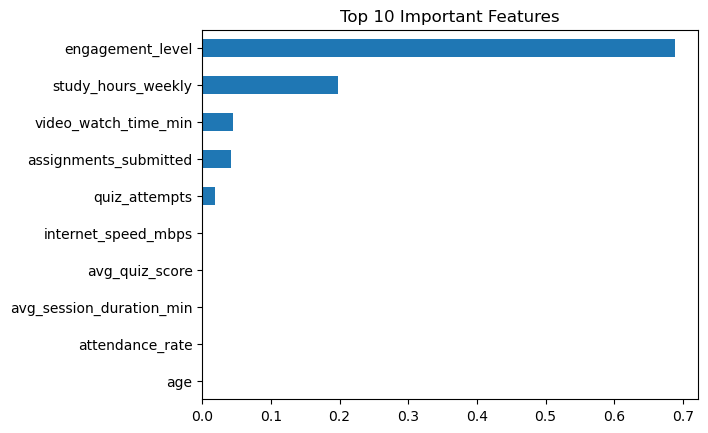

In [91]:
import matplotlib.pyplot as plt

importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

# 🚀 Step 6: Build Recommendation System

In [92]:
def recommend(level):
    if level == 0:
        return "Low engagement → Increase study hours and login frequency."
    elif level == 1:
        return "Medium engagement → Maintain consistency and improve quiz performance."
    else:
        return "High engagement → Excellent! Continue your learning pattern."

# Test
sample_pred = model.predict(X_test.iloc[:1])
print(recommend(sample_pred[0]))

Medium engagement → Maintain consistency and improve quiz performance.


# Let's build a Deep Learning Layer Model

#### Why ANN (instead of LSTM here)?

👉 Your data is:

Tabular ✔
Not sequential ❌

So:

ANN = correct model choice (not LSTM)

## Make sure engagement_level has correct input

In [109]:
df['engagement_level'] = pd.qcut(
    df['engagement_score'],
    q=3,
    labels=[0, 1, 2]
)

# 🔥 VERY IMPORTANT FIX
df['engagement_level'] = df['engagement_level'].astype(int)

print(df['engagement_level'].value_counts())

engagement_level
2    16667
0    16667
1    16666
Name: count, dtype: int64


# Feature Selection

In [111]:
X = df.drop([
    'engagement_score',
    'engagement_level',
    'student_id',
    'final_grade',
    'dropout'
], axis=1)

y = df['engagement_level']

# Encode Categorical Features

In [113]:
X = pd.get_dummies(X, drop_first=True)

### 🚀 Step 1: Normalize the Data (VERY IMPORTANT)
ANN needs scaled inputs 👇

In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### ✂️ Step 2: Stratified Train/Test Split

In [115]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # ⭐ CRITICAL
)

print("y_train:\n", y_train.value_counts())
print("y_test:\n", y_test.value_counts())

y_train:
 engagement_level
2    13334
1    13333
0    13333
Name: count, dtype: int64
y_test:
 engagement_level
0    3334
1    3333
2    3333
Name: count, dtype: int64


### 🧠 Step 3: Build ANN Model

In [116]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                     │ (None, 128)                 │           2,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,995 (50.76 KB)

 Trainable params: 12,995 (50.76 KB)

 Non-trainable params: 0 (0.00 B)

### 🚀 Step 5: Train Model

In [117]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weights   # optional
)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8731 - loss: 0.2790 - val_accuracy: 0.9655 - val_loss: 0.0927
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9441 - loss: 0.1280 - val_accuracy: 0.9755 - val_loss: 0.0663
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9585 - loss: 0.0995 - val_accuracy: 0.9792 - val_loss: 0.0542
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9658 - loss: 0.0815 - val_accuracy: 0.9833 - val_loss: 0.0445
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9705 - loss: 0.0725 - val_accuracy: 0.9821 - val_loss: 0.0419
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9734 - loss: 0.0630 - val_accuracy: 0.9810 - val_loss: 0.0417
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9757 - loss: 0.0591 - val_accuracy: 0.9820 - val_loss: 0.0431
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9768 - loss: 0.0565 - 

# 🔍 Step 6: Predict

In [118]:
import numpy as np

y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("Unique predictions:", np.unique(y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Unique predictions: [0 1 2]


# 📊 Step 7: Evaluate Model

In [119]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_classes))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_classes))

Accuracy: 0.9879

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3334
           1       0.98      0.99      0.98      3333
           2       1.00      0.99      0.99      3333

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Confusion Matrix:

[[3301   33    0]
 [  26 3292   15]
 [   0   47 3286]]


# Training Curves (VERY IMPORTANT FOR Research)

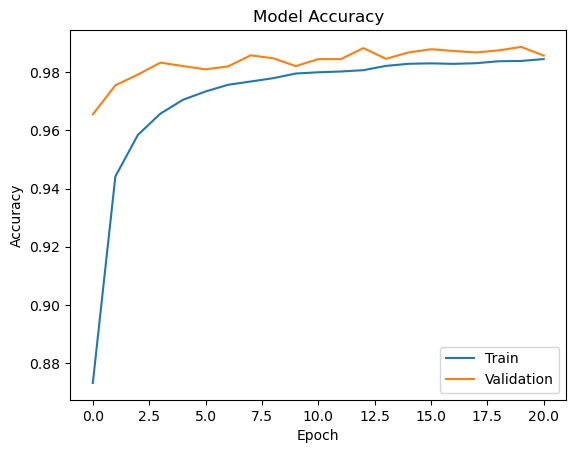

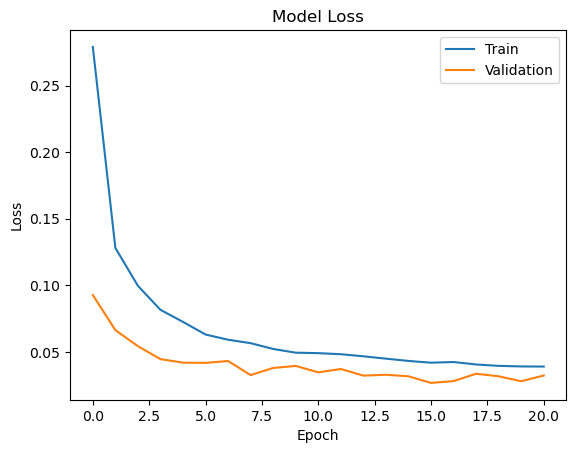

In [120]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# More Visulaization:

### 📊 1. Confusion Matrix Heatmap

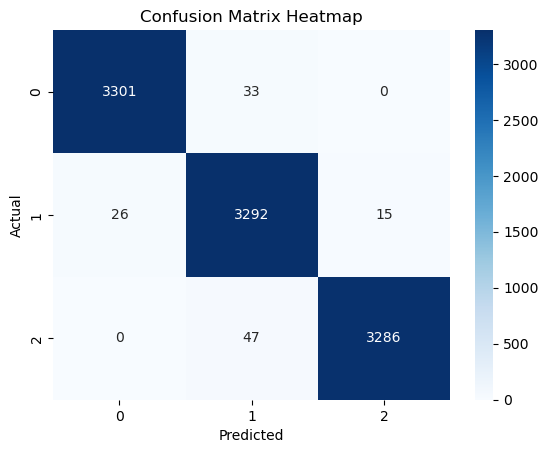

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

### 📈 2. ROC Curve (Multi-class)

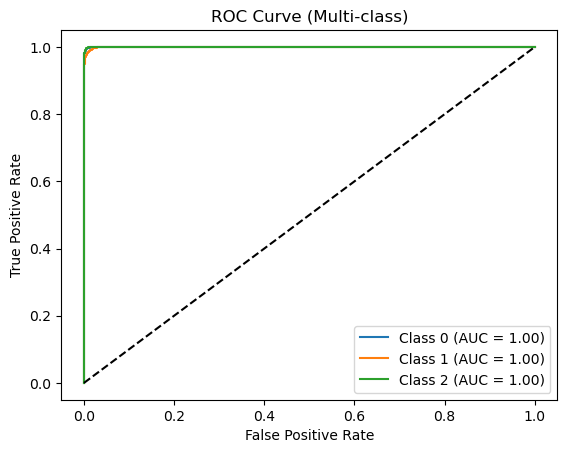

In [122]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {auc(fpr,tpr):.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()

### 📉 3. Precision-Recall Curve

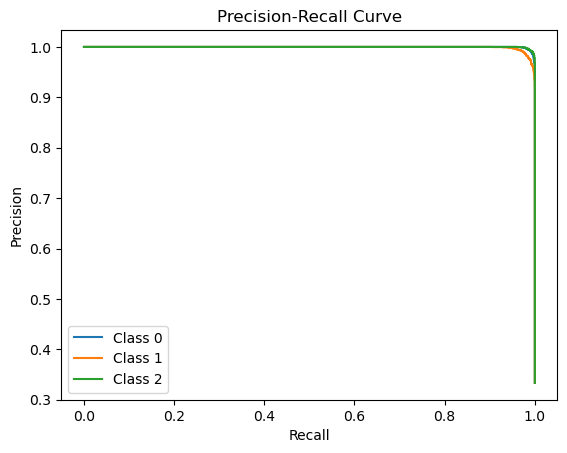

In [123]:
from sklearn.metrics import precision_recall_curve

for i in range(3):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_probs[:, i])
    plt.plot(recall, precision, label=f"Class {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

### 🔍 4. Feature Importance (from RandomForest)

Need to define RandomForest at first

In [130]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

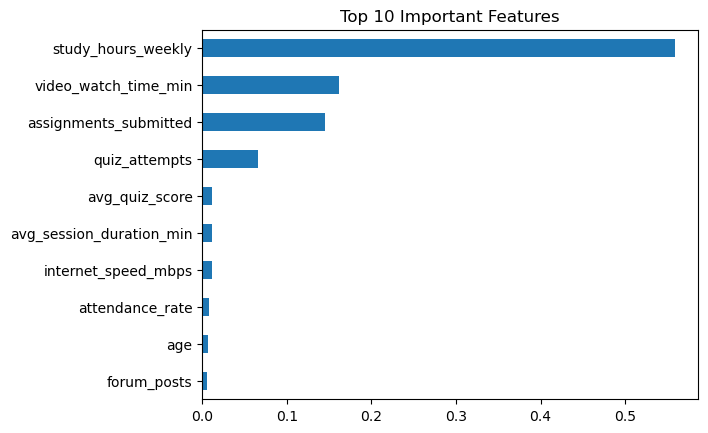

In [131]:
import pandas as pd

rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
rf_importance.sort_values(ascending=False).head(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

### 📊 5. Prediction Distribution

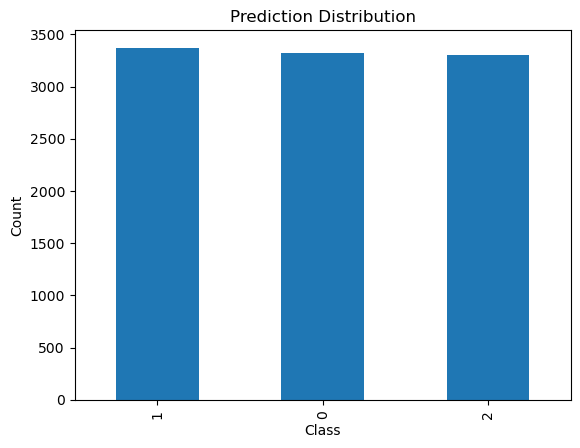

In [125]:
import pandas as pd

pd.Series(y_pred_classes).value_counts().plot(kind='bar')
plt.title("Prediction Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### 📉 6. True vs Predicted Comparison

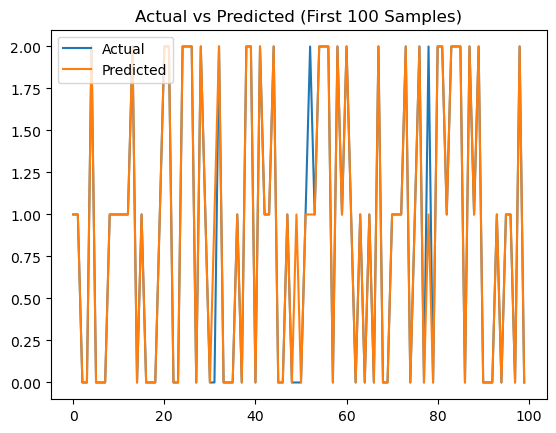

In [126]:
plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred_classes[:100], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted (First 100 Samples)")
plt.show()

### 📊 7. Correlation Heatmap (Before Modeling)

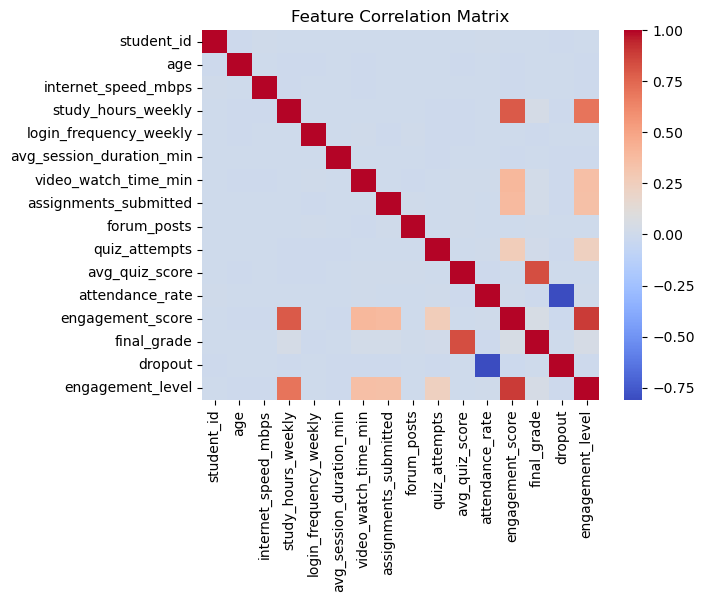

In [127]:
import seaborn as sns

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

### 📉 8. Learning Curve (Advanced 🔥)
👉 Detect overfitting

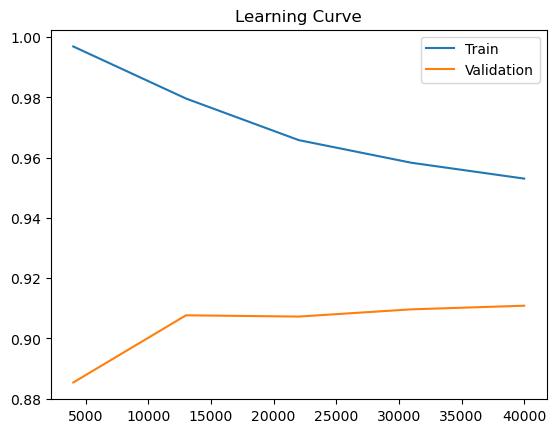

In [132]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X, y, cv=5
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Validation')
plt.legend()
plt.title("Learning Curve")
plt.show()

### 📊 9. Class-wise Accuracy Visualization

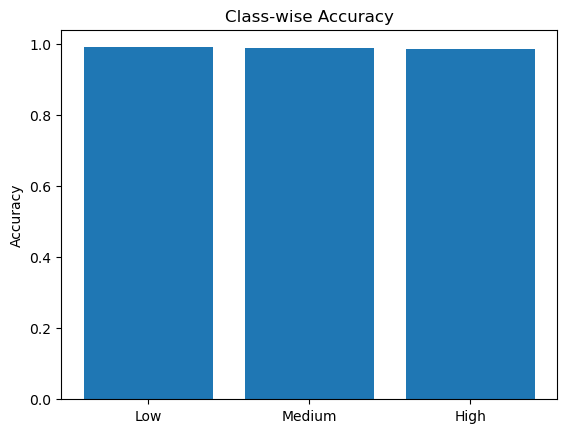

In [129]:
import numpy as np

cm = confusion_matrix(y_test, y_pred_classes)

class_acc = cm.diagonal() / cm.sum(axis=1)

plt.bar(['Low','Medium','High'], class_acc)
plt.title("Class-wise Accuracy")
plt.ylabel("Accuracy")
plt.show()